# Movie Genre Classification

## CodSoft Machine Learning Internship — Task 1

### Objective

Build a machine learning model that predicts the genre of a movie from its plot summary using natural language processing and supervised machine learning.

### Final Approach

- Text representation: TF-IDF
- Models evaluated:
  - Multinomial Naive Bayes
  - Logistic Regression
  - Linear SVM
- Final model: Balanced Linear SVM
- Final hyperparameter: C = 0.5
- Evaluation metrics: Accuracy, Macro F1, Weighted F1

## 1. Problem Statement

Movie genre classification is a text classification problem in which the model predicts the genre of a movie from its plot summary.

The input to the model is the movie plot text and the target variable is the movie genre.

This can support applications such as movie catalog organization, metadata enrichment, recommendation systems, and automated content tagging.

## 2. Dataset

The dataset contains movie records with the following fields:

- `ID` — unique movie identifier
- `TITLE` — movie title
- `GENRE` — target genre
- `PLOT` — movie plot summary

The training dataset contains 54,214 records and 27 unique genres.

The supplied test dataset contains 54,200 records, with the corresponding genre labels provided separately in `test_data_solution.txt`.

import pandas as pd

train_path = "../data/Genre Classification Dataset/train_data.txt"

train_df = pd.read_csv(
    train_path,
    sep=" ::: ",
    engine="python",
    header=None,
    names=["ID", "TITLE", "GENRE", "PLOT"]
)

train_df.head()

In [2]:
print("Dataset shape:", train_df.shape)

print("\nColumn names:")
print(train_df.columns.tolist())

print("\nData types:")
print(train_df.dtypes)

print("\nMissing values:")
print(train_df.isnull().sum())

Dataset shape: (54214, 4)

Column names:
['ID', 'TITLE', 'GENRE', 'PLOT']

Data types:
ID       int64
TITLE      str
GENRE      str
PLOT       str
dtype: object

Missing values:
ID       0
TITLE    0
GENRE    0
PLOT     0
dtype: int64


In [3]:
print("Number of unique genres:", train_df["GENRE"].nunique())

print("\nGenres:")
print(train_df["GENRE"].unique())

Number of unique genres: 27

Genres:
<ArrowStringArray>
[      'drama',    'thriller',       'adult', 'documentary',      'comedy',
       'crime',  'reality-tv',      'horror',       'sport',   'animation',
      'action',     'fantasy',       'short',      'sci-fi',       'music',
   'adventure',   'talk-show',     'western',      'family',     'mystery',
     'history',        'news',   'biography',     'romance',   'game-show',
     'musical',         'war']
Length: 27, dtype: str


In [4]:
genre_counts = train_df["GENRE"].value_counts()

print(genre_counts)

GENRE
drama          13613
documentary    13096
comedy          7447
short           5073
horror          2204
thriller        1591
action          1315
western         1032
reality-tv       884
family           784
adventure        775
music            731
romance          672
sci-fi           647
adult            590
crime            505
animation        498
sport            432
talk-show        391
fantasy          323
mystery          319
musical          277
biography        265
history          243
game-show        194
news             181
war              132
Name: count, dtype: int64


In [5]:
print("Duplicate complete rows:", train_df.duplicated().sum())

print("Duplicate movie IDs:", train_df["ID"].duplicated().sum())

print("Duplicate plots:", train_df["PLOT"].duplicated().sum())

Duplicate complete rows: 0
Duplicate movie IDs: 0
Duplicate plots: 128


In [6]:
train_df["plot_word_count"] = train_df["PLOT"].str.split().str.len()

print(train_df["plot_word_count"].describe())

count    54214.000000
mean       101.907386
std         76.579192
min          6.000000
25%         55.000000
50%         79.000000
75%        121.000000
max       1829.000000
Name: plot_word_count, dtype: float64


In [7]:
test_path = "../data/Genre Classification Dataset/test_data.txt"
solution_path = "../data/Genre Classification Dataset/test_data_solution.txt"

test_df = pd.read_csv(
    test_path,
    sep=" ::: ",
    engine="python",
    header=None,
    names=["ID", "TITLE", "PLOT"]
)

test_solution_df = pd.read_csv(
    solution_path,
    sep=" ::: ",
    engine="python",
    header=None,
    names=["ID", "TITLE", "GENRE", "PLOT"]
)

print("Test data shape:", test_df.shape)
print("Test solution shape:", test_solution_df.shape)

print("\nTest data columns:")
print(test_df.columns.tolist())

print("\nTest solution columns:")
print(test_solution_df.columns.tolist())

Test data shape: (54200, 3)
Test solution shape: (54200, 4)

Test data columns:
['ID', 'TITLE', 'PLOT']

Test solution columns:
['ID', 'TITLE', 'GENRE', 'PLOT']


In [8]:
print("Test IDs unique:", test_df["ID"].is_unique)
print("Solution IDs unique:", test_solution_df["ID"].is_unique)

print(
    "IDs match:",
    test_df["ID"].equals(test_solution_df["ID"])
)

Test IDs unique: True
Solution IDs unique: True
IDs match: True


In [9]:
print("Missing values in test data:")
print(test_df.isnull().sum())

print("\nMissing values in test solution:")
print(test_solution_df.isnull().sum())

Missing values in test data:
ID       0
TITLE    0
PLOT     0
dtype: int64

Missing values in test solution:
ID       0
TITLE    0
GENRE    0
PLOT     0
dtype: int64


In [10]:
train_genres = set(train_df["GENRE"].unique())
test_genres = set(test_solution_df["GENRE"].unique())

print("Genres in training data:", len(train_genres))
print("Genres in test solution:", len(test_genres))

print("\nGenres only in training data:")
print(sorted(train_genres - test_genres))

print("\nGenres only in test data:")
print(sorted(test_genres - train_genres))

Genres in training data: 27
Genres in test solution: 27

Genres only in training data:
[]

Genres only in test data:
[]


Matplotlib is building the font cache; this may take a moment.


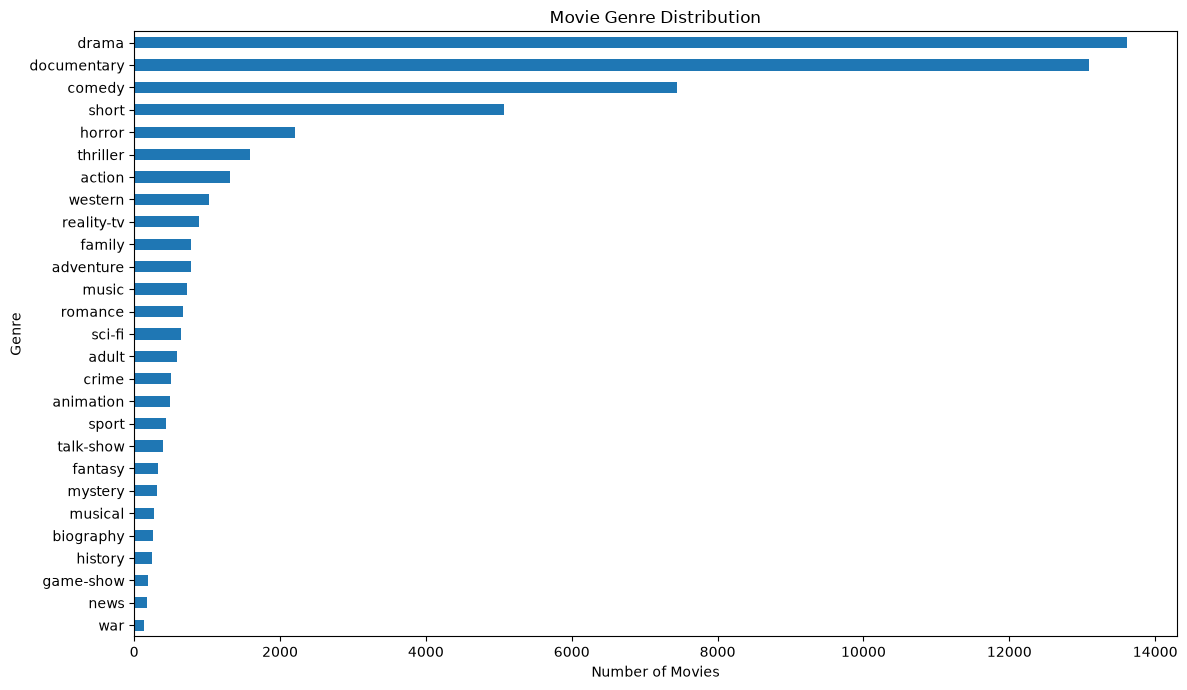

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 7))

genre_counts.sort_values().plot(kind="barh")

plt.title("Movie Genre Distribution")
plt.xlabel("Number of Movies")
plt.ylabel("Genre")
plt.tight_layout()
plt.show()

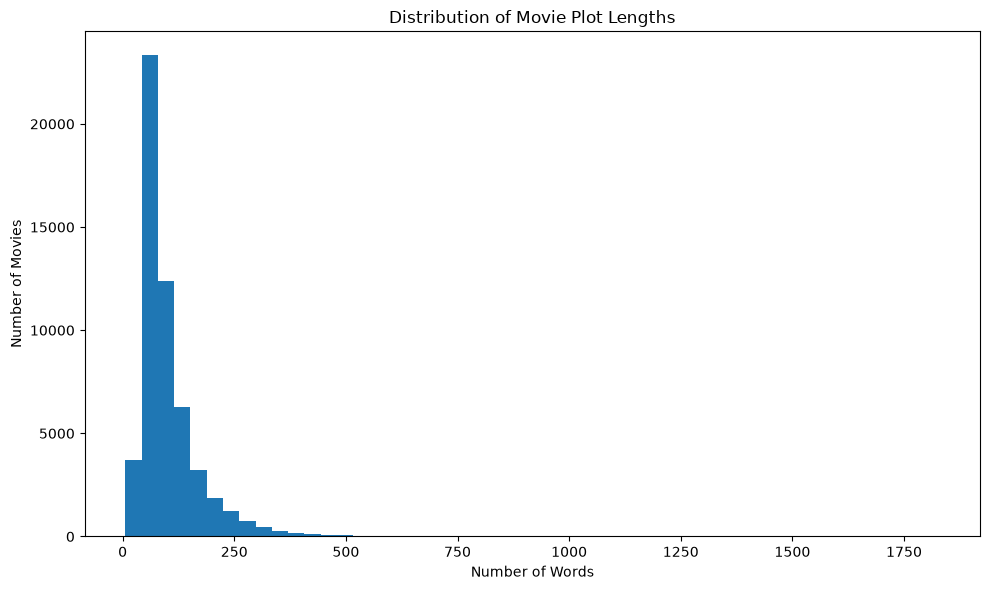

In [12]:
plt.figure(figsize=(10, 6))

plt.hist(
    train_df["plot_word_count"],
    bins=50
)

plt.title("Distribution of Movie Plot Lengths")
plt.xlabel("Number of Words")
plt.ylabel("Number of Movies")
plt.tight_layout()
plt.show()

In [13]:
genre_plot_stats = (
    train_df.groupby("GENRE")["plot_word_count"]
    .agg(["count", "mean", "median"])
    .sort_values("mean", ascending=False)
)

genre_plot_stats

,count,mean,median
GENRE,,,
game-show,194,131.226804,73.0
western,1032,121.597868,83.0
mystery,319,112.924765,77.0
romance,672,112.331845,93.0
war,132,111.848485,80.0
drama,13613,108.894953,84.0
documentary,13096,107.440440,86.0
biography,265,106.479245,85.0
horror,2204,104.302632,78.0


In [14]:
duplicate_plots = train_df[
    train_df["PLOT"].duplicated(keep=False)
].sort_values("PLOT")

duplicate_plot_genres = (
    duplicate_plots.groupby("PLOT")["GENRE"]
    .nunique()
)

print(
    "Duplicate plots with conflicting genres:",
    (duplicate_plot_genres > 1).sum()
)

Duplicate plots with conflicting genres: 15


In [15]:
conflicting_plots = (
    duplicate_plots
    .groupby("PLOT")
    .filter(lambda group: group["GENRE"].nunique() > 1)
)

conflicting_plots[
    ["ID", "TITLE", "GENRE", "PLOT"]
].sort_values("PLOT")

,ID,TITLE,GENRE,PLOT
2773,2774,The 14th Annual People's Choice Awards (1988),documentary,"""People' s Choice Awards"" - American award, th..."
17577,17578,The 3rd Annual People's Choice Awards (1977),reality-tv,"""People' s Choice Awards"" - American award, th..."
17765,17766,The 5th Annual People's Choice Awards (1979),reality-tv,"""People' s Choice Awards"" - American award, th..."
27304,27305,The 18th Annual People's Choice Awards (1992),family,"""People' s Choice Awards"" - American award, th..."
35641,35642,The 38th Annual People's Choice Awards (2012),talk-show,"""People' s Choice Awards"" - American award, th..."
39037,39038,The 28th Annual People's Choice Awards (2002),family,"""People' s Choice Awards"" - American award, th..."
6089,6090,"""Quattro piccole donne"" (1989)",drama,'Louisa May Alcott' (qv)'s autobiographical ac...
31729,31730,"""Mulherzinhas"" (1959)",romance,'Louisa May Alcott' (qv)'s autobiographical ac...
3323,3324,Onkel Vanja (1994),drama,A retired professor has returned to his estate...
11645,11646,Onkel Wanja - Bilder aus dem Landleben (1971),comedy,A retired professor has returned to his estate...


In [16]:
train_plots = set(train_df["PLOT"])
test_plots = set(test_df["PLOT"])

overlap_plots = train_plots.intersection(test_plots)

print("Unique train plots:", len(train_plots))
print("Unique test plots:", len(test_plots))
print("Plot overlap between train and test:", len(overlap_plots))

Unique train plots: 54086
Unique test plots: 54072
Plot overlap between train and test: 91


In [17]:
duplicate_plot_analysis = (
    duplicate_plots
    .groupby("PLOT")
    .agg(
        number_of_records=("ID", "count"),
        unique_titles=("TITLE", "nunique"),
        unique_genres=("GENRE", "nunique")
    )
)

duplicate_plot_analysis.describe()

,number_of_records,unique_titles,unique_genres
count,76.000000,76.000000,76.000000
mean,2.684211,2.684211,1.250000
std,1.884750,1.884750,0.568624
min,2.000000,2.000000,1.000000
25%,2.000000,2.000000,1.000000
50%,2.000000,2.000000,1.000000
75%,2.000000,2.000000,1.000000
max,12.000000,12.000000,4.000000


In [18]:
print(
    "Duplicate plots shared by multiple titles:",
    (duplicate_plot_analysis["unique_titles"] > 1).sum()
)

print(
    "Duplicate plots with multiple genres:",
    (duplicate_plot_analysis["unique_genres"] > 1).sum()
)

Duplicate plots shared by multiple titles: 76
Duplicate plots with multiple genres: 15


In [19]:
conflicting_examples = (
    duplicate_plots
    .groupby("PLOT")
    .filter(lambda group: group["GENRE"].nunique() > 1)
    .sort_values("PLOT")
)

print("Number of conflicting duplicate groups:",
      conflicting_examples["PLOT"].nunique())

conflicting_examples[
    ["ID", "TITLE", "GENRE", "PLOT"]
]

Number of conflicting duplicate groups: 15


,ID,TITLE,GENRE,PLOT
2773,2774,The 14th Annual People's Choice Awards (1988),documentary,"""People' s Choice Awards"" - American award, th..."
17577,17578,The 3rd Annual People's Choice Awards (1977),reality-tv,"""People' s Choice Awards"" - American award, th..."
17765,17766,The 5th Annual People's Choice Awards (1979),reality-tv,"""People' s Choice Awards"" - American award, th..."
27304,27305,The 18th Annual People's Choice Awards (1992),family,"""People' s Choice Awards"" - American award, th..."
35641,35642,The 38th Annual People's Choice Awards (2012),talk-show,"""People' s Choice Awards"" - American award, th..."
39037,39038,The 28th Annual People's Choice Awards (2002),family,"""People' s Choice Awards"" - American award, th..."
6089,6090,"""Quattro piccole donne"" (1989)",drama,'Louisa May Alcott' (qv)'s autobiographical ac...
31729,31730,"""Mulherzinhas"" (1959)",romance,'Louisa May Alcott' (qv)'s autobiographical ac...
3323,3324,Onkel Vanja (1994),drama,A retired professor has returned to his estate...
11645,11646,Onkel Wanja - Bilder aus dem Landleben (1971),comedy,A retired professor has returned to his estate...


In [20]:
overlap_analysis = (
    train_df[train_df["PLOT"].isin(overlap_plots)]
    [["ID", "TITLE", "GENRE", "PLOT"]]
    .merge(
        test_solution_df[
            test_solution_df["PLOT"].isin(overlap_plots)
        ][["ID", "TITLE", "GENRE", "PLOT"]],
        on="PLOT",
        suffixes=("_train", "_test")
    )
)

print("Overlapping plot pairs:", len(overlap_analysis))

print(
    "Same genre:",
    (
        overlap_analysis["GENRE_train"]
        == overlap_analysis["GENRE_test"]
    ).sum()
)

print(
    "Different genre:",
    (
        overlap_analysis["GENRE_train"]
        != overlap_analysis["GENRE_test"]
    ).sum()
)

Overlapping plot pairs: 560
Same genre: 430
Different genre: 130


In [21]:
overlap_summary = (
    pd.concat([
        train_df[train_df["PLOT"].isin(overlap_plots)]
        [["PLOT", "GENRE"]]
        .assign(SOURCE="TRAIN"),

        test_solution_df[test_solution_df["PLOT"].isin(overlap_plots)]
        [["PLOT", "GENRE"]]
        .assign(SOURCE="TEST")
    ])
    .groupby(["PLOT", "SOURCE"])["GENRE"]
    .agg(lambda x: sorted(set(x)))
    .unstack("SOURCE")
)

overlap_summary["train_test_genres_match"] = (
    overlap_summary["TRAIN"] == overlap_summary["TEST"]
)

print("Unique overlapping plots:", len(overlap_summary))

print(
    "Plots with identical genre sets:",
    overlap_summary["train_test_genres_match"].sum()
)

print(
    "Plots with different genre sets:",
    (~overlap_summary["train_test_genres_match"]).sum()
)

Unique overlapping plots: 91
Plots with identical genre sets: 65
Plots with different genre sets: 26


In [22]:
problematic_overlaps = overlap_summary[
    ~overlap_summary["train_test_genres_match"]
]

print("Number of inconsistent overlapping plots:",
      len(problematic_overlaps))

problematic_overlaps

Number of inconsistent overlapping plots: 26


SOURCE,TEST,TRAIN,train_test_genres_match
PLOT,,,
"""People' s Choice Awards"" - American award, that is awarded to the figures of pop culture on results the spectator voting. Handed annually, since 1975. 2005 to of winner in each of nominations found out by means of the sociological questioning, and then voting was organized in the Internet.",[family],"[documentary, family, reality-tv, talk-show]",False
"'Louisa May Alcott' (qv)'s autobiographical account of her life with her three sisters in Concord, Massachusetts in the 1860s. With their father fighting in the American Civil War, sisters Jo, Meg, Amy and Beth are at home with their mother, a very outspoken women for her time. The story tells of how the sisters grow up, find love and find their place in the world.",[drama],"[drama, romance]",False
"A promising young pianist commits suicide. He spent his last evening in the company of the industrialist Friedrich Hofreiter. His wife Genia is in possession of a farewell note, in which the pianist explains that she had refused to have an affair with him and that he had shot himself out of unrequited love. Genia's sacrifice and commitment to marital fidelity cause the notorious womanizer Hofreiter to hastily leave for the mountains, where he begins a new affair. During his absence, Genia embarks on an affair with Otto, the son of an acquaintance. When Hofreiter returns and finds out about his wife's adultery, he challenges Otto to a duel and kills him.",[drama],[comedy],False
"A retired professor has returned to his estate to live with his beautiful young wife, Yelena. The estate originally belonged to his first wife, now deceased; her mother and brother still live there and manage the farm. For many years the brother (Uncle Vanya) has sent the farm's proceeds to the professor, while receiving only a small salary himself. Sonya, the professor's daughter, who is about the same age as his new wife, also lives on the estate. The professor is pompous, vain, and irritable. He calls the doctor (Astrov) to treat his gout, only to send him away without seeing him. Astrov is an experienced physician who performs his job conscientiously, but has lost all idealism and spends much of his time drinking. The presence of Yelena introduces a bit of sexual tension into the household. Astrov and Uncle Vanya both fall in love with Yelena; she spurns them both. Meanwhile, Sonya is in love with Astrov, who fails even to notice her. Finally, when the professor announces he wants to sell the estate, Vanya, whose admiration for the man died with his sister, tries to kill him.",[drama],"[comedy, drama]",False
"A rich merchant, Antonio is depressed for no good reason, until his good friend Bassanio comes to tell him how he's in love with Portia. Portia's father has died and left a very strange will: only the man that picks the correct casket out of three (silver, gold, and lead) can marry her. Bassanio, unfortunately, is strapped for cash with which to go wooing, and Antonio wants to help, so Antonio borrows the money from Shylock, the money-lender. But Shylock has been nursing a grudge against Antonio's insults, and makes unusual terms to the loan. And when Antonio's business fails, those terms threaten his life, and it's up to Bassanio and Portia to save him.",[drama],"[comedy, drama]",False
"Award of the American academy of cinematographic arts and sciences, from 1940th known as ""Oscar"", - American film award created in 1929 and traditionally handed to the figures of cinematographic art for their contribution to creation of movies.",[family],"[documentary, family]",False
"Billed as ""the theatrical event of the season"" when first released, this epic film chronicles the current days of a theatre company that began in the 1960's. The founding members are attempting to pass the torch to a younger generation who, accomplished in their own right, have different ideas of how things should be done in the future.",[comedy],[drama],False
"Blessed encompasses

In [23]:
# Identify plot texts with conflicting genre labels
conflicting_plot_texts = set(
    conflicting_examples["PLOT"].unique()
)

print(
    "Conflicting plot groups to exclude:",
    len(conflicting_plot_texts)
)

Conflicting plot groups to exclude: 15


In [24]:
model_df = train_df[
    ~train_df["PLOT"].isin(conflicting_plot_texts)
].copy()

print("Original training rows:", len(train_df))
print("Rows after removing conflicting plots:", len(model_df))
print(
    "Rows removed:",
    len(train_df) - len(model_df)
)

Original training rows: 54214
Rows after removing conflicting plots: 54156
Rows removed: 58


## 3. Data Quality and Cleaning

Initial inspection identified:

- 54,214 training records
- 27 unique genre classes
- No missing values in the training data
- 128 repeated plot texts
- 15 plot groups with conflicting genre labels
- Duplicate `PLOT + GENRE` combinations were also present

The original source files were preserved unchanged.

For model development, plot groups with conflicting genre labels were excluded because assigning an arbitrary genre would introduce label ambiguity. Exact duplicate `PLOT + GENRE` combinations were removed.

The resulting modeling dataset contained 54,071 records with no remaining duplicate plot texts or conflicting genre labels.

In [25]:
before_dedup = len(model_df)

model_df = model_df.drop_duplicates(
    subset=["PLOT", "GENRE"]
).copy()

print("Rows before deduplication:", before_dedup)
print("Rows after deduplication:", len(model_df))
print(
    "Duplicate rows removed:",
    before_dedup - len(model_df)
)

Rows before deduplication: 54156
Rows after deduplication: 54071
Duplicate rows removed: 85


In [26]:
print("Clean modeling dataset shape:", model_df.shape)

print("\nMissing values:")
print(model_df[["TITLE", "GENRE", "PLOT"]].isnull().sum())

print("\nDuplicate plot + genre combinations:")
print(
    model_df.duplicated(
        subset=["PLOT", "GENRE"]
    ).sum()
)

Clean modeling dataset shape: (54071, 5)

Missing values:
TITLE    0
GENRE    0
PLOT     0
dtype: int64

Duplicate plot + genre combinations:
0


In [27]:
remaining_conflicts = (
    model_df.groupby("PLOT")["GENRE"]
    .nunique()
)

print(
    "Plots with conflicting genres remaining:",
    (remaining_conflicts > 1).sum()
)

Plots with conflicting genres remaining: 0


In [28]:
cleaned_path = "../outputs/movie_genre_cleaned.csv"

model_df.to_csv(
    cleaned_path,
    index=False
)

print("Cleaned dataset saved to:", cleaned_path)

Cleaned dataset saved to: ../outputs/movie_genre_cleaned.csv


In [29]:
plot_frequency = model_df["PLOT"].value_counts()

print(
    "Unique plots:",
    model_df["PLOT"].nunique()
)

print(
    "Plots appearing more than once:",
    (plot_frequency > 1).sum()
)

print(
    "Maximum records sharing one plot:",
    plot_frequency.max()
)

Unique plots: 54071
Plots appearing more than once: 0
Maximum records sharing one plot: 1


In [30]:
from sklearn.model_selection import train_test_split

In [31]:
X = model_df["PLOT"]
y = model_df["GENRE"]

print("Input samples:", len(X))
print("Target samples:", len(y))
print("Number of classes:", y.nunique())

Input samples: 54071
Target samples: 54071
Number of classes: 27


In [32]:
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Validation samples:", len(X_val))

Training samples: 43256
Validation samples: 10815


In [33]:
split_check = pd.DataFrame({
    "Train": y_train.value_counts(normalize=True),
    "Validation": y_val.value_counts(normalize=True)
}).fillna(0)

split_check["Difference"] = (
    split_check["Train"] - split_check["Validation"]
)

split_check.sort_values(
    "Train",
    ascending=False
)

,Train,Validation,Difference
GENRE,,,
drama,0.250925,0.250948,-2.303054e-05
documentary,0.241839,0.241886,-4.698666e-05
comedy,0.137253,0.137309,-5.665718e-05
short,0.093606,0.093574,3.177120e-05
horror,0.040757,0.040777,-1.934745e-05
thriller,0.029406,0.029404,2.719031e-06
action,0.024274,0.024318,-4.398760e-05
western,0.019096,0.019048,4.799775e-05
reality-tv,0.016321,0.016274,4.774123e-05


In [34]:
print(
    "Maximum class proportion difference:",
    split_check["Difference"].abs().max()
)

Maximum class proportion difference: 5.6657176562863176e-05


In [35]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, f1_score

baseline_model = DummyClassifier(
    strategy="most_frequent"
)

baseline_model.fit(X_train, y_train)

baseline_predictions = baseline_model.predict(X_val)

baseline_accuracy = accuracy_score(
    y_val,
    baseline_predictions
)

baseline_macro_f1 = f1_score(
    y_val,
    baseline_predictions,
    average="macro",
    zero_division=0
)

baseline_weighted_f1 = f1_score(
    y_val,
    baseline_predictions,
    average="weighted",
    zero_division=0
)

print("Baseline Accuracy:", baseline_accuracy)
print("Baseline Macro F1:", baseline_macro_f1)
print("Baseline Weighted F1:", baseline_weighted_f1)

Baseline Accuracy: 0.25094775774387423
Baseline Macro F1: 0.014859711511348735
Baseline Weighted F1: 0.10068330468133264


In [36]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [37]:
tfidf_vectorizer = TfidfVectorizer(
    lowercase=True,
    strip_accents="unicode",
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True,
    max_features=100000
)

In [38]:
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)

print("Training TF-IDF shape:", X_train_tfidf.shape)

Training TF-IDF shape: (43256, 100000)


In [40]:
X_val_tfidf = tfidf_vectorizer.transform(X_val)

print("Validation TF-IDF shape:", X_val_tfidf.shape)

Validation TF-IDF shape: (10815, 100000)


In [41]:
print(
    "Vocabulary size:",
    len(tfidf_vectorizer.vocabulary_)
)

Vocabulary size: 100000


In [42]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [43]:
tfidf_vectorizer = TfidfVectorizer(
    lowercase=True,
    strip_accents="unicode",
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True,
    max_features=100000
)

In [46]:
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)

print("Training TF-IDF shape:", X_train_tfidf.shape)

Training TF-IDF shape: (43256, 100000)


In [47]:
X_val_tfidf = tfidf_vectorizer.transform(X_val)

print("Validation TF-IDF shape:", X_val_tfidf.shape)

Validation TF-IDF shape: (10815, 100000)


In [48]:
from sklearn.naive_bayes import MultinomialNB

In [49]:
nb_model = MultinomialNB(alpha=1.0)

nb_model.fit(X_train_tfidf, y_train)

print("Naive Bayes model trained successfully.")

Naive Bayes model trained successfully.


In [50]:
nb_predictions = nb_model.predict(X_val_tfidf)

print("Predictions generated:", len(nb_predictions))

Predictions generated: 10815


In [51]:
from sklearn.metrics import accuracy_score, f1_score

nb_accuracy = accuracy_score(
    y_val,
    nb_predictions
)

nb_macro_f1 = f1_score(
    y_val,
    nb_predictions,
    average="macro",
    zero_division=0
)

nb_weighted_f1 = f1_score(
    y_val,
    nb_predictions,
    average="weighted",
    zero_division=0
)

print("Naive Bayes Accuracy:", nb_accuracy)
print("Naive Bayes Macro F1:", nb_macro_f1)
print("Naive Bayes Weighted F1:", nb_weighted_f1)

Naive Bayes Accuracy: 0.45196486361534904
Naive Bayes Macro F1: 0.05291520873691053
Naive Bayes Weighted F1: 0.32107795907957754


In [52]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_val,
        nb_predictions,
        zero_division=0
    )
)

              precision    recall  f1-score   support

      action       0.00      0.00      0.00       263
       adult       0.00      0.00      0.00       118
   adventure       0.00      0.00      0.00       155
   animation       0.00      0.00      0.00        99
   biography       0.00      0.00      0.00        53
      comedy       0.62      0.10      0.17      1485
       crime       0.00      0.00      0.00       101
 documentary       0.53      0.91      0.67      2616
       drama       0.39      0.87      0.54      2714
      family       0.00      0.00      0.00       155
     fantasy       0.00      0.00      0.00        64
   game-show       0.00      0.00      0.00        39
     history       0.00      0.00      0.00        49
      horror       1.00      0.00      0.00       441
       music       0.00      0.00      0.00       144
     musical       0.00      0.00      0.00        55
     mystery       0.00      0.00      0.00        64
        news       0.00    

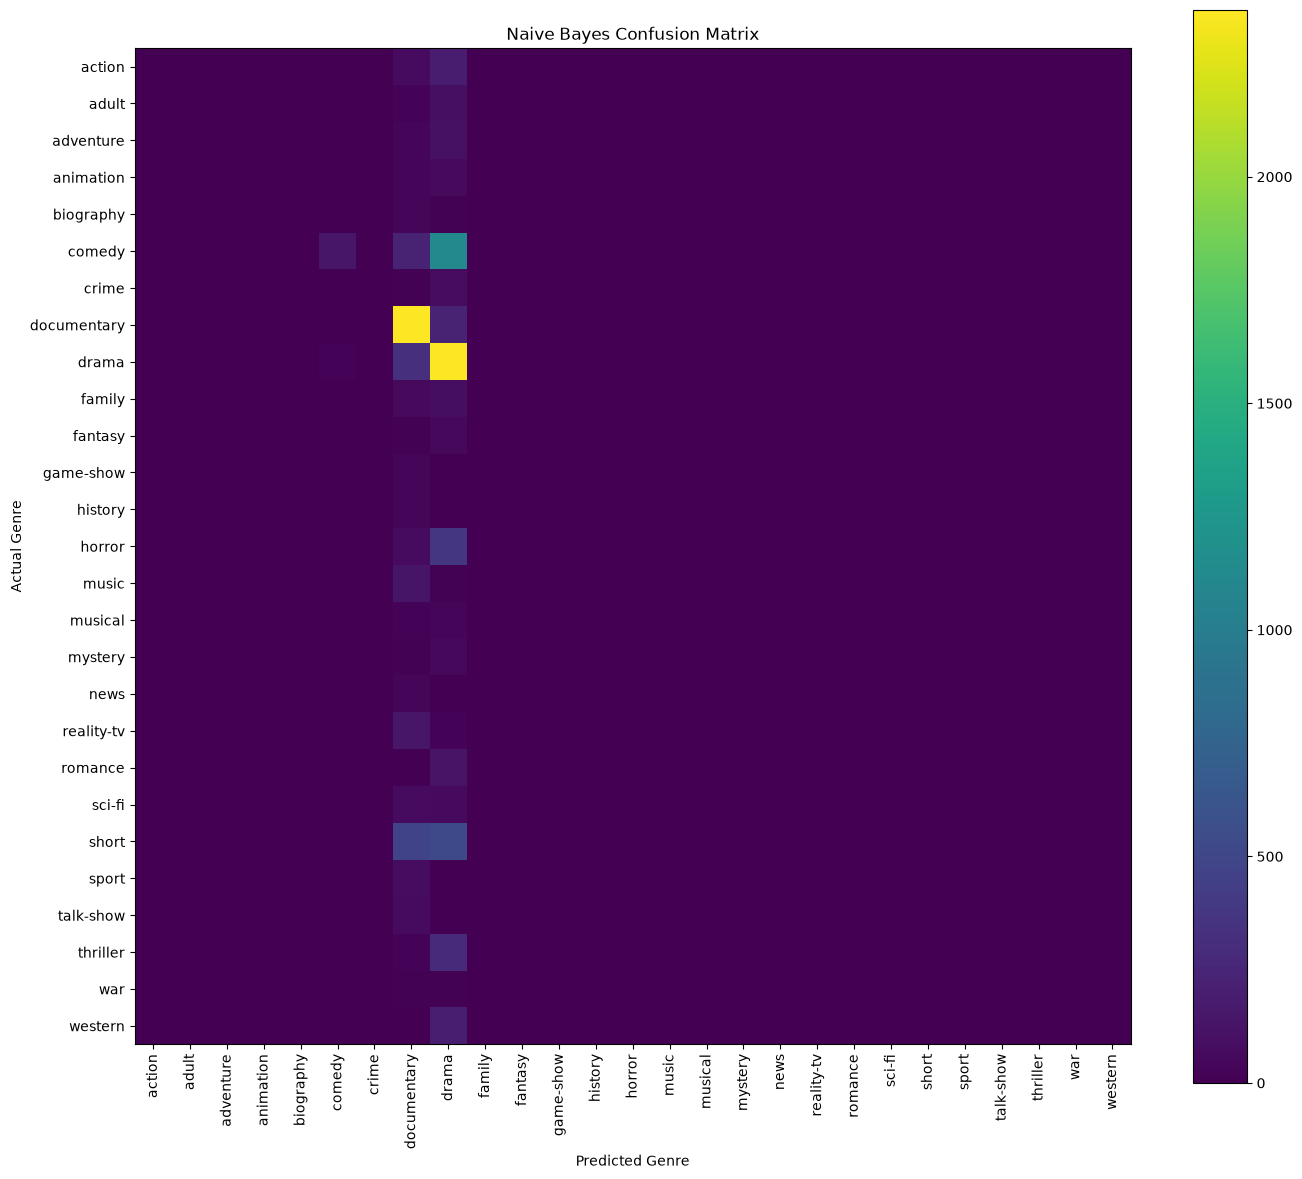

In [53]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm_nb = confusion_matrix(
    y_val,
    nb_predictions,
    labels=nb_model.classes_
)

plt.figure(figsize=(14, 12))

plt.imshow(cm_nb)

plt.title("Naive Bayes Confusion Matrix")
plt.xlabel("Predicted Genre")
plt.ylabel("Actual Genre")

plt.xticks(
    range(len(nb_model.classes_)),
    nb_model.classes_,
    rotation=90
)

plt.yticks(
    range(len(nb_model.classes_)),
    nb_model.classes_
)

plt.colorbar()

plt.tight_layout()
plt.show()

In [54]:
comparison = pd.DataFrame({
    "Model": [
        "Majority Baseline",
        "Multinomial Naive Bayes"
    ],
    "Accuracy": [
        baseline_accuracy,
        nb_accuracy
    ],
    "Macro F1": [
        baseline_macro_f1,
        nb_macro_f1
    ],
    "Weighted F1": [
        baseline_weighted_f1,
        nb_weighted_f1
    ]
})

comparison

,Model,Accuracy,Macro F1,Weighted F1
0,Majority Baseline,0.250948,0.014860,0.100683
1,Multinomial Naive Bayes,0.451965,0.052915,0.321078


In [55]:
from sklearn.linear_model import LogisticRegression

In [59]:
lr_predictions = lr_model.predict(X_val_tfidf)

print("Predictions generated:", len(lr_predictions))

Predictions generated: 10815


In [60]:
lr_accuracy = accuracy_score(
    y_val,
    lr_predictions
)

lr_macro_f1 = f1_score(
    y_val,
    lr_predictions,
    average="macro",
    zero_division=0
)

lr_weighted_f1 = f1_score(
    y_val,
    lr_predictions,
    average="weighted",
    zero_division=0
)

print("Logistic Regression Accuracy:", lr_accuracy)
print("Logistic Regression Macro F1:", lr_macro_f1)
print("Logistic Regression Weighted F1:", lr_weighted_f1)

Logistic Regression Accuracy: 0.5843735552473417
Logistic Regression Macro F1: 0.23629876718938186
Logistic Regression Weighted F1: 0.5268213191225266


In [61]:
print(
    classification_report(
        y_val,
        lr_predictions,
        zero_division=0
    )
)

              precision    recall  f1-score   support

      action       0.60      0.16      0.26       263
       adult       0.73      0.14      0.23       118
   adventure       0.88      0.10      0.17       155
   animation       0.75      0.03      0.06        99
   biography       0.00      0.00      0.00        53
      comedy       0.54      0.59      0.57      1485
       crime       0.00      0.00      0.00       101
 documentary       0.65      0.90      0.75      2616
       drama       0.53      0.82      0.64      2714
      family       1.00      0.02      0.04       155
     fantasy       0.00      0.00      0.00        64
   game-show       1.00      0.33      0.50        39
     history       0.00      0.00      0.00        49
      horror       0.67      0.49      0.57       441
       music       0.69      0.31      0.42       144
     musical       0.00      0.00      0.00        55
     mystery       0.00      0.00      0.00        64
        news       0.00    

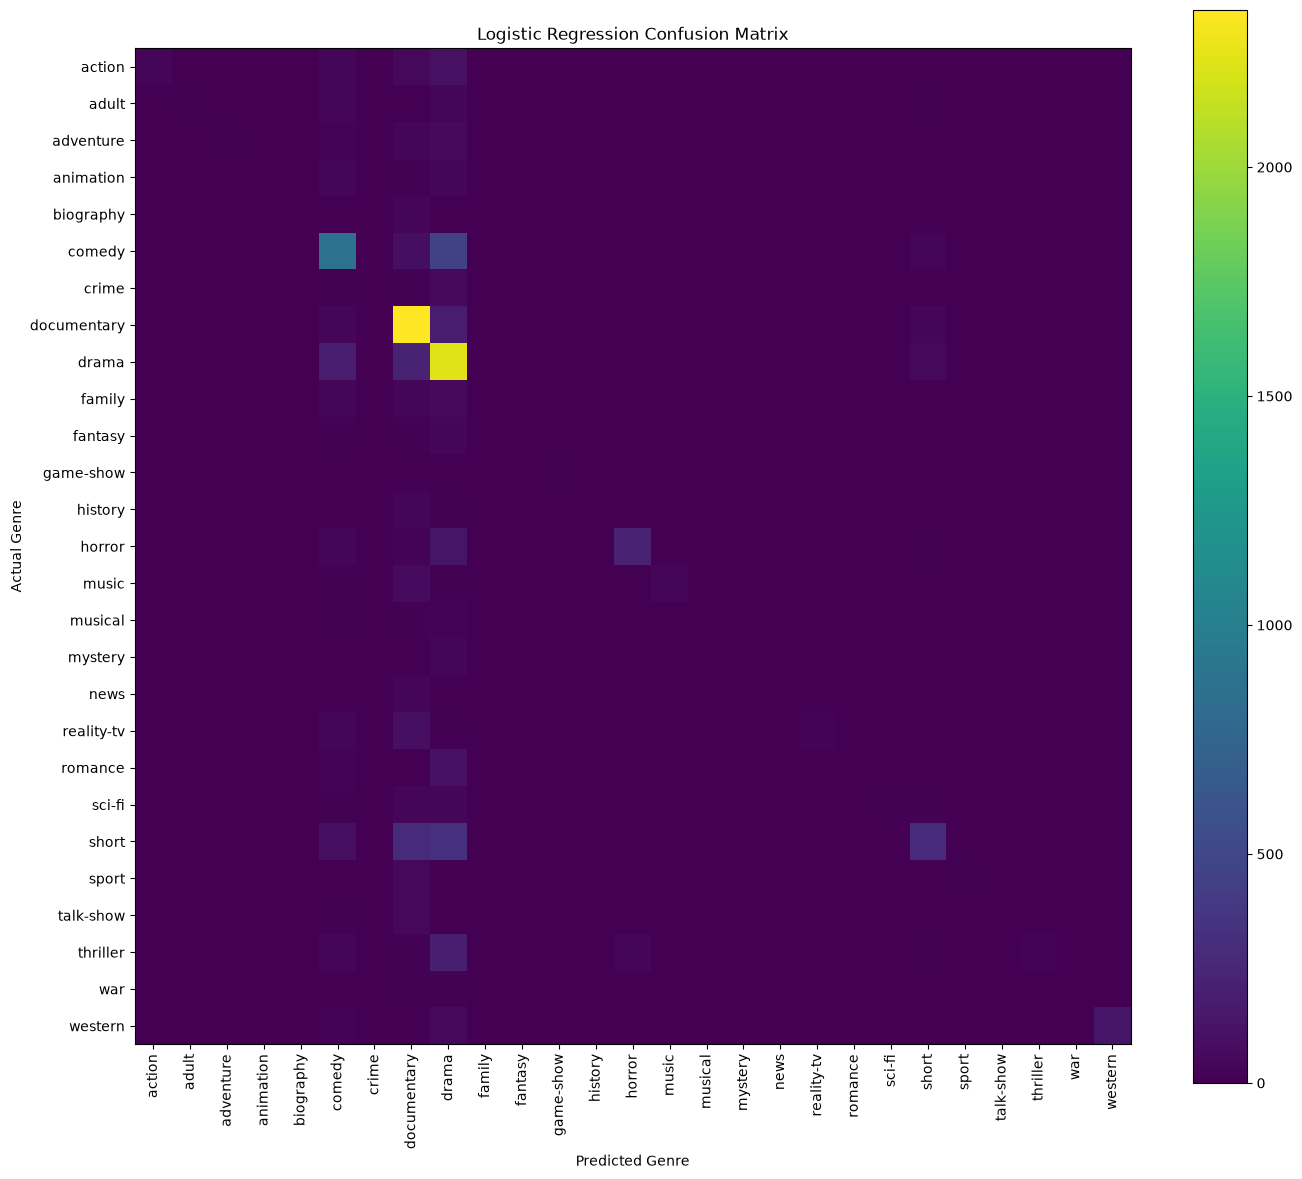

In [62]:
cm_lr = confusion_matrix(
    y_val,
    lr_predictions,
    labels=lr_model.classes_
)

plt.figure(figsize=(14, 12))

plt.imshow(cm_lr)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted Genre")
plt.ylabel("Actual Genre")

plt.xticks(
    range(len(lr_model.classes_)),
    lr_model.classes_,
    rotation=90
)

plt.yticks(
    range(len(lr_model.classes_)),
    lr_model.classes_
)

plt.colorbar()

plt.tight_layout()
plt.show()

In [63]:
comparison = pd.DataFrame({
    "Model": [
        "Majority Baseline",
        "Multinomial Naive Bayes",
        "Logistic Regression"
    ],
    "Accuracy": [
        baseline_accuracy,
        nb_accuracy,
        lr_accuracy
    ],
    "Macro F1": [
        baseline_macro_f1,
        nb_macro_f1,
        lr_macro_f1
    ],
    "Weighted F1": [
        baseline_weighted_f1,
        nb_weighted_f1,
        lr_weighted_f1
    ]
})

comparison

,Model,Accuracy,Macro F1,Weighted F1
0,Majority Baseline,0.250948,0.014860,0.100683
1,Multinomial Naive Bayes,0.451965,0.052915,0.321078
2,Logistic Regression,0.584374,0.236299,0.526821


In [64]:
from sklearn.svm import LinearSVC

In [65]:
svm_model = LinearSVC(
    C=1.0,
    class_weight=None,
    random_state=42
)

svm_model.fit(X_train_tfidf, y_train)

print("Linear SVM model trained successfully.")

Linear SVM model trained successfully.


In [66]:
svm_predictions = svm_model.predict(X_val_tfidf)

print("Predictions generated:", len(svm_predictions))

Predictions generated: 10815


In [67]:
svm_accuracy = accuracy_score(
    y_val,
    svm_predictions
)

svm_macro_f1 = f1_score(
    y_val,
    svm_predictions,
    average="macro",
    zero_division=0
)

svm_weighted_f1 = f1_score(
    y_val,
    svm_predictions,
    average="weighted",
    zero_division=0
)

print("Linear SVM Accuracy:", svm_accuracy)
print("Linear SVM Macro F1:", svm_macro_f1)
print("Linear SVM Weighted F1:", svm_weighted_f1)

Linear SVM Accuracy: 0.6016643550624133
Linear SVM Macro F1: 0.3519488347555066
Linear SVM Weighted F1: 0.5693158271006129


In [68]:
print(
    classification_report(
        y_val,
        svm_predictions,
        zero_division=0
    )
)

              precision    recall  f1-score   support

      action       0.47      0.31      0.38       263
       adult       0.70      0.40      0.51       118
   adventure       0.44      0.15      0.23       155
   animation       0.44      0.11      0.18        99
   biography       0.00      0.00      0.00        53
      comedy       0.55      0.61      0.58      1485
       crime       0.19      0.03      0.05       101
 documentary       0.70      0.86      0.77      2616
       drama       0.56      0.74      0.64      2714
      family       0.42      0.09      0.15       155
     fantasy       0.44      0.06      0.11        64
   game-show       0.93      0.64      0.76        39
     history       0.00      0.00      0.00        49
      horror       0.66      0.65      0.65       441
       music       0.63      0.51      0.56       144
     musical       0.00      0.00      0.00        55
     mystery       0.22      0.03      0.05        64
        news       0.44    

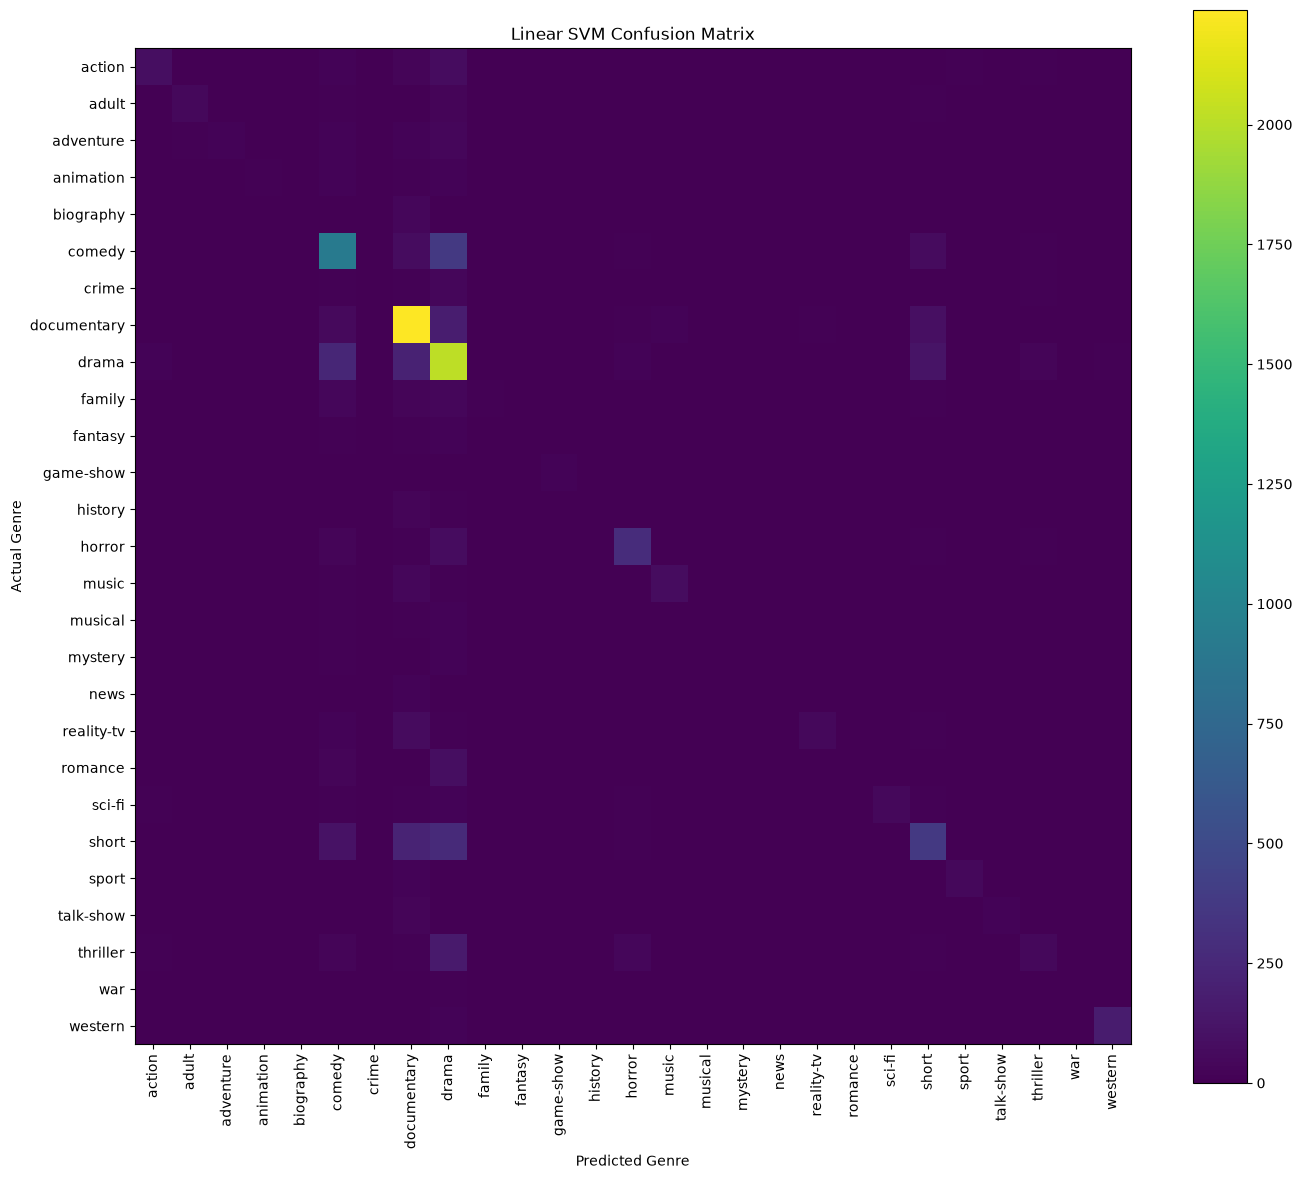

In [69]:
cm_svm = confusion_matrix(
    y_val,
    svm_predictions,
    labels=svm_model.classes_
)

plt.figure(figsize=(14, 12))

plt.imshow(cm_svm)

plt.title("Linear SVM Confusion Matrix")
plt.xlabel("Predicted Genre")
plt.ylabel("Actual Genre")

plt.xticks(
    range(len(svm_model.classes_)),
    svm_model.classes_,
    rotation=90
)

plt.yticks(
    range(len(svm_model.classes_)),
    svm_model.classes_
)

plt.colorbar()

plt.tight_layout()
plt.show()

## 4. Model Comparison

Three text-classification approaches were evaluated using the same TF-IDF representation and the same validation split:

1. Multinomial Naive Bayes
2. Logistic Regression
3. Linear SVM

A majority-class classifier was also used as a baseline.

Linear SVM produced the strongest overall validation performance among the initial models.

In [70]:
comparison = pd.DataFrame({
    "Model": [
        "Majority Baseline",
        "Multinomial Naive Bayes",
        "Logistic Regression",
        "Linear SVM"
    ],
    "Accuracy": [
        baseline_accuracy,
        nb_accuracy,
        lr_accuracy,
        svm_accuracy
    ],
    "Macro F1": [
        baseline_macro_f1,
        nb_macro_f1,
        lr_macro_f1,
        svm_macro_f1
    ],
    "Weighted F1": [
        baseline_weighted_f1,
        nb_weighted_f1,
        lr_weighted_f1,
        svm_weighted_f1
    ]
})

comparison.sort_values(
    "Macro F1",
    ascending=False
)

,Model,Accuracy,Macro F1,Weighted F1
3,Linear SVM,0.601664,0.351949,0.569316
2,Logistic Regression,0.584374,0.236299,0.526821
1,Multinomial Naive Bayes,0.451965,0.052915,0.321078
0,Majority Baseline,0.250948,0.014860,0.100683


In [71]:
svm_report = classification_report(
    y_val,
    svm_predictions,
    zero_division=0,
    output_dict=True
)

svm_report_df = pd.DataFrame(svm_report).T

svm_report_df.sort_values(
    "f1-score",
    ascending=True
).head(10)

,precision,recall,f1-score,support
musical,0.000000,0.000000,0.000000,55.0
history,0.000000,0.000000,0.000000,49.0
biography,0.000000,0.000000,0.000000,53.0
crime,0.187500,0.029703,0.051282,101.0
romance,0.307692,0.029851,0.054422,134.0
mystery,0.222222,0.031250,0.054795,64.0
fantasy,0.444444,0.062500,0.109589,64.0
family,0.424242,0.090323,0.148936,155.0
animation,0.440000,0.111111,0.177419,99.0
news,0.444444,0.111111,0.177778,36.0


In [72]:
svm_report_df.loc[
    svm_report_df.index.isin(svm_model.classes_)
].sort_values(
    "f1-score",
    ascending=False
).head(10)

,precision,recall,f1-score,support
western,0.867347,0.825243,0.845771,206.0
documentary,0.703960,0.856269,0.772680,2616.0
game-show,0.925926,0.641026,0.757576,39.0
horror,0.658986,0.648526,0.653714,441.0
drama,0.563180,0.743920,0.641054,2714.0
sport,0.695652,0.558140,0.619355,86.0
comedy,0.553127,0.613468,0.581737,1485.0
music,0.629310,0.506944,0.561538,144.0
adult,0.701493,0.398305,0.508108,118.0
sci-fi,0.578947,0.341085,0.429268,129.0


In [73]:
error_analysis_df = pd.DataFrame({
    "PLOT": X_val.reset_index(drop=True),
    "ACTUAL": y_val.reset_index(drop=True),
    "PREDICTED": pd.Series(svm_predictions)
})

errors = error_analysis_df[
    error_analysis_df["ACTUAL"] != error_analysis_df["PREDICTED"]
].copy()

print("Total validation samples:", len(error_analysis_df))
print("Misclassified samples:", len(errors))
print(
    "Validation error rate:",
    len(errors) / len(error_analysis_df)
)

Total validation samples: 10815
Misclassified samples: 4308
Validation error rate: 0.39833564493758666


In [74]:
confusion_pairs = (
    errors.groupby(
        ["ACTUAL", "PREDICTED"]
    )
    .size()
    .reset_index(name="COUNT")
    .sort_values(
        "COUNT",
        ascending=False
    )
)

confusion_pairs.head(15)

,ACTUAL,PREDICTED,COUNT
61,comedy,drama,374
233,short,drama,271
103,drama,comedy,243
232,short,documentary,223
105,drama,documentary,218
87,documentary,drama,181
260,thriller,drama,159
114,drama,short,118
231,short,comedy,105
94,documentary,short,89


In [75]:
genre_performance = svm_report_df.loc[
    svm_report_df.index.isin(svm_model.classes_),
    ["precision", "recall", "f1-score", "support"]
].copy()

genre_performance.sort_values(
    "support",
    ascending=False
).head(10)

,precision,recall,f1-score,support
drama,0.563180,0.743920,0.641054,2714.0
documentary,0.703960,0.856269,0.772680,2616.0
comedy,0.553127,0.613468,0.581737,1485.0
short,0.464151,0.364625,0.408412,1012.0
horror,0.658986,0.648526,0.653714,441.0
thriller,0.328767,0.150943,0.206897,318.0
action,0.473988,0.311787,0.376147,263.0
western,0.867347,0.825243,0.845771,206.0
reality-tv,0.566667,0.289773,0.383459,176.0
family,0.424242,0.090323,0.148936,155.0


In [76]:
genre_performance.sort_values(
    "support",
    ascending=True
).head(10)

,precision,recall,f1-score,support
war,0.857143,0.230769,0.363636,26.0
news,0.444444,0.111111,0.177778,36.0
game-show,0.925926,0.641026,0.757576,39.0
history,0.000000,0.000000,0.000000,49.0
biography,0.000000,0.000000,0.000000,53.0
musical,0.000000,0.000000,0.000000,55.0
mystery,0.222222,0.031250,0.054795,64.0
fantasy,0.444444,0.062500,0.109589,64.0
talk-show,0.611111,0.285714,0.389381,77.0
sport,0.695652,0.558140,0.619355,86.0


In [77]:
balanced_svm_model = LinearSVC(
    C=1.0,
    class_weight="balanced",
    random_state=42
)

balanced_svm_model.fit(
    X_train_tfidf,
    y_train
)

print("Balanced Linear SVM trained successfully.")

Balanced Linear SVM trained successfully.


In [78]:
balanced_svm_predictions = balanced_svm_model.predict(
    X_val_tfidf
)

print(
    "Predictions generated:",
    len(balanced_svm_predictions)
)

Predictions generated: 10815


In [79]:
balanced_svm_accuracy = accuracy_score(
    y_val,
    balanced_svm_predictions
)

balanced_svm_macro_f1 = f1_score(
    y_val,
    balanced_svm_predictions,
    average="macro",
    zero_division=0
)

balanced_svm_weighted_f1 = f1_score(
    y_val,
    balanced_svm_predictions,
    average="weighted",
    zero_division=0
)

print("Balanced SVM Accuracy:", balanced_svm_accuracy)
print("Balanced SVM Macro F1:", balanced_svm_macro_f1)
print(
    "Balanced SVM Weighted F1:",
    balanced_svm_weighted_f1
)

Balanced SVM Accuracy: 0.5963938973647711
Balanced SVM Macro F1: 0.3960613454027087
Balanced SVM Weighted F1: 0.5889687127735838


## 5. Hyperparameter Tuning

Class weighting was introduced to address the strong imbalance between the 27 genres.

The balanced Linear SVM improved Macro F1 from approximately 35.19% to 39.61%.

Three values of `C` were evaluated:

- `C = 0.5`
- `C = 1.0`
- `C = 2.0`

The best configuration based on Macro F1 was:

**Linear SVM + `class_weight="balanced"` + `C=0.5`**

This configuration achieved approximately:

- Accuracy: 58.71%
- Macro F1: 39.79%
- Weighted F1: 58.55%

In [80]:
svm_improvement = pd.DataFrame({
    "Model": [
        "Linear SVM",
        "Balanced Linear SVM"
    ],
    "Accuracy": [
        svm_accuracy,
        balanced_svm_accuracy
    ],
    "Macro F1": [
        svm_macro_f1,
        balanced_svm_macro_f1
    ],
    "Weighted F1": [
        svm_weighted_f1,
        balanced_svm_weighted_f1
    ]
})

svm_improvement

,Model,Accuracy,Macro F1,Weighted F1
0,Linear SVM,0.601664,0.351949,0.569316
1,Balanced Linear SVM,0.596394,0.396061,0.588969


In [81]:
svm_c05 = LinearSVC(
    C=0.5,
    class_weight="balanced",
    random_state=42
)

svm_c05.fit(X_train_tfidf, y_train)

pred_c05 = svm_c05.predict(X_val_tfidf)

acc_c05 = accuracy_score(y_val, pred_c05)
macro_f1_c05 = f1_score(
    y_val,
    pred_c05,
    average="macro",
    zero_division=0
)
weighted_f1_c05 = f1_score(
    y_val,
    pred_c05,
    average="weighted",
    zero_division=0
)

print("C=0.5 Accuracy:", acc_c05)
print("C=0.5 Macro F1:", macro_f1_c05)
print("C=0.5 Weighted F1:", weighted_f1_c05)

C=0.5 Accuracy: 0.5871474803513639
C=0.5 Macro F1: 0.3979101935017025
C=0.5 Weighted F1: 0.5855140821150973


In [82]:
svm_c2 = LinearSVC(
    C=2.0,
    class_weight="balanced",
    random_state=42
)

svm_c2.fit(X_train_tfidf, y_train)

pred_c2 = svm_c2.predict(X_val_tfidf)

acc_c2 = accuracy_score(y_val, pred_c2)
macro_f1_c2 = f1_score(
    y_val,
    pred_c2,
    average="macro",
    zero_division=0
)
weighted_f1_c2 = f1_score(
    y_val,
    pred_c2,
    average="weighted",
    zero_division=0
)

print("C=2.0 Accuracy:", acc_c2)
print("C=2.0 Macro F1:", macro_f1_c2)
print("C=2.0 Weighted F1:", weighted_f1_c2)

C=2.0 Accuracy: 0.594914470642626
C=2.0 Macro F1: 0.39009831771986975
C=2.0 Weighted F1: 0.5835905533915112


In [83]:
svm_tuning_results = pd.DataFrame({
    "C": [0.5, 1.0, 2.0],
    "Accuracy": [
        acc_c05,
        balanced_svm_accuracy,
        acc_c2
    ],
    "Macro F1": [
        macro_f1_c05,
        balanced_svm_macro_f1,
        macro_f1_c2
    ],
    "Weighted F1": [
        weighted_f1_c05,
        balanced_svm_weighted_f1,
        weighted_f1_c2
    ]
})

svm_tuning_results.sort_values(
    "Macro F1",
    ascending=False
)

,C,Accuracy,Macro F1,Weighted F1
0,0.5,0.587147,0.397910,0.585514
1,1.0,0.596394,0.396061,0.588969
2,2.0,0.594914,0.390098,0.583591


In [84]:
final_svm_model = LinearSVC(
    C=0.5,
    class_weight="balanced",
    random_state=42
)

final_svm_model.fit(X_train_tfidf, y_train)

final_val_predictions = final_svm_model.predict(X_val_tfidf)

print("Final validation model trained successfully.")

Final validation model trained successfully.


In [85]:
final_accuracy = accuracy_score(
    y_val,
    final_val_predictions
)

final_macro_f1 = f1_score(
    y_val,
    final_val_predictions,
    average="macro",
    zero_division=0
)

final_weighted_f1 = f1_score(
    y_val,
    final_val_predictions,
    average="weighted",
    zero_division=0
)

print("Final Validation Accuracy:", final_accuracy)
print("Final Validation Macro F1:", final_macro_f1)
print("Final Validation Weighted F1:", final_weighted_f1)

Final Validation Accuracy: 0.5871474803513639
Final Validation Macro F1: 0.3979101935017025
Final Validation Weighted F1: 0.5855140821150973


In [86]:
final_report = classification_report(
    y_val,
    final_val_predictions,
    zero_division=0
)

print(final_report)

              precision    recall  f1-score   support

      action       0.36      0.47      0.41       263
       adult       0.50      0.73      0.59       118
   adventure       0.27      0.25      0.26       155
   animation       0.23      0.23      0.23        99
   biography       0.10      0.04      0.05        53
      comedy       0.62      0.58      0.60      1485
       crime       0.18      0.21      0.20       101
 documentary       0.76      0.80      0.78      2616
       drama       0.69      0.58      0.63      2714
      family       0.21      0.19      0.20       155
     fantasy       0.12      0.11      0.12        64
   game-show       0.76      0.74      0.75        39
     history       0.10      0.04      0.06        49
      horror       0.55      0.76      0.64       441
       music       0.42      0.67      0.52       144
     musical       0.22      0.15      0.17        55
     mystery       0.14      0.11      0.12        64
        news       0.31    

In [87]:
import joblib

model_path = "../models/movie_genre_svm.pkl"

joblib.dump(
    final_svm_model,
    model_path
)

print("Final model saved to:", model_path)

Final model saved to: ../models/movie_genre_svm.pkl


In [88]:
vectorizer_path = "../models/movie_genre_tfidf.pkl"

joblib.dump(
    tfidf_vectorizer,
    vectorizer_path
)

print("TF-IDF vectorizer saved to:", vectorizer_path)

TF-IDF vectorizer saved to: ../models/movie_genre_tfidf.pkl


In [89]:
X_test = test_df["PLOT"]

y_test = test_solution_df["GENRE"]

print("Official test samples:", len(X_test))
print("Official test labels:", len(y_test))
print("Test samples and labels match:", len(X_test) == len(y_test))

Official test samples: 54200
Official test labels: 54200
Test samples and labels match: True


In [90]:
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print("Official test TF-IDF shape:", X_test_tfidf.shape)
print("Training TF-IDF shape:", X_train_tfidf.shape)

Official test TF-IDF shape: (54200, 100000)
Training TF-IDF shape: (43256, 100000)


In [91]:
final_test_predictions = final_svm_model.predict(
    X_test_tfidf
)

print(
    "Official test predictions generated:",
    len(final_test_predictions)
)

Official test predictions generated: 54200


## 6. Official Test Evaluation

The final model was evaluated on the supplied test dataset using the provided `test_data_solution.txt` labels.

The official test benchmark achieved approximately:

- Accuracy: 58.25%
- Macro F1: 39.10%
- Weighted F1: approximately 58.3%

The supplied dataset contains repeated plot texts between the training and test data, including cases where genre sets differ. Therefore, this result is reported as the official supplied-dataset benchmark rather than as a completely leakage-free estimate of generalization.

In [92]:
official_test_accuracy = accuracy_score(
    y_test,
    final_test_predictions
)

official_test_macro_f1 = f1_score(
    y_test,
    final_test_predictions,
    average="macro",
    zero_division=0
)

official_test_weighted_f1 = f1_score(
    y_test,
    final_test_predictions,
    average="weighted",
    zero_division=0
)

print("Official Test Accuracy:", official_test_accuracy)
print("Official Test Macro F1:", official_test_macro_f1)
print(
    "Official Test Weighted F1:",
    official_test_weighted_f1
)

Official Test Accuracy: 0.5824723247232473
Official Test Macro F1: 0.3910144847595856
Official Test Weighted F1: 0.580327595432372


In [93]:
new_movie_plot = """
A young detective returns to her hometown after many years and begins
investigating a series of mysterious disappearances. As she follows
clues through the old neighborhoods, she discovers that the cases are
connected to a secret from her family's past.
"""

new_movie_tfidf = tfidf_vectorizer.transform(
    [new_movie_plot]
)

predicted_genre = final_svm_model.predict(
    new_movie_tfidf
)[0]

print("Predicted Genre:", predicted_genre)

Predicted Genre: horror


In [94]:
sample_movies = [
    {
        "title": "The Missing Case",
        "plot": """
        A detective investigates a series of unexplained disappearances
        and discovers a hidden connection between the victims.
        """
    },
    {
        "title": "The Last Concert",
        "plot": """
        A struggling musician gets one final opportunity to perform
        on a major stage while trying to rebuild her career.
        """
    },
    {
        "title": "Battle for the Kingdom",
        "plot": """
        A young prince leads an army against an invading force to reclaim
        his kingdom after years of conflict.
        """
    }
]

sample_texts = [movie["plot"] for movie in sample_movies]

sample_tfidf = tfidf_vectorizer.transform(sample_texts)

sample_predictions = final_svm_model.predict(sample_tfidf)

prediction_results = pd.DataFrame({
    "Movie": [movie["title"] for movie in sample_movies],
    "Predicted Genre": sample_predictions
})

prediction_results

,Movie,Predicted Genre
0,The Missing Case,thriller
1,The Last Concert,comedy
2,Battle for the Kingdom,fantasy


## 7. New Movie Prediction

The trained pipeline was also tested on previously unseen example plot summaries.

The complete prediction pipeline is:

**Movie Plot → TF-IDF Transformation → Final Linear SVM → Predicted Genre**

Example predictions were generated for:

- The Missing Case
- The Last Concert
- Battle for the Kingdom

## 8. Conclusion

This project implemented an end-to-end movie genre classification pipeline using natural language processing and supervised machine learning.

After data validation, cleaning, exploratory analysis, TF-IDF feature extraction, model comparison, error analysis, and hyperparameter tuning, the final model was selected as a balanced Linear SVM with `C=0.5`.

The final model achieved approximately 39.79% Macro F1 on the internal validation set and approximately 39.10% Macro F1 on the supplied official test benchmark.

The project demonstrates how text-based machine learning can be used to automatically classify movie genres from plot summaries.